In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

import pylib.Chebyschev_coefs as ch

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

12192
/media/work/docs/codes/QuCF/scripts-py


In [3]:
path_save_scan_ = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_ = "../QuCF/simulations/Stepanoff/init_dirdec"
for i in range(100):
    plt.close()

import qiskit
from qiskit.quantum_info import Operator, SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit
from qiskit.circuit.library import DiagonalGate
print("qiskit version: ", qiskit.version.get_version_info())

qiskit version:  1.3.2


Reading the file ../QuCF/simulations/Stepanoff/init_dirdec/init_dirdec_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is init_dirdec
Simulation has been performed  02-13-2025 09:59:22
max-abs-err: 7.772e-16


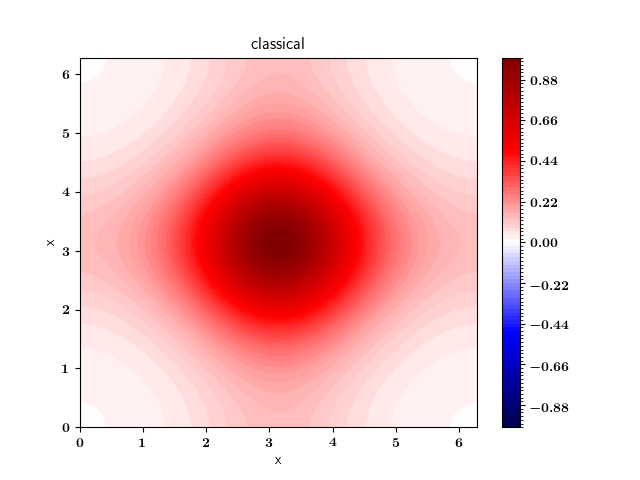

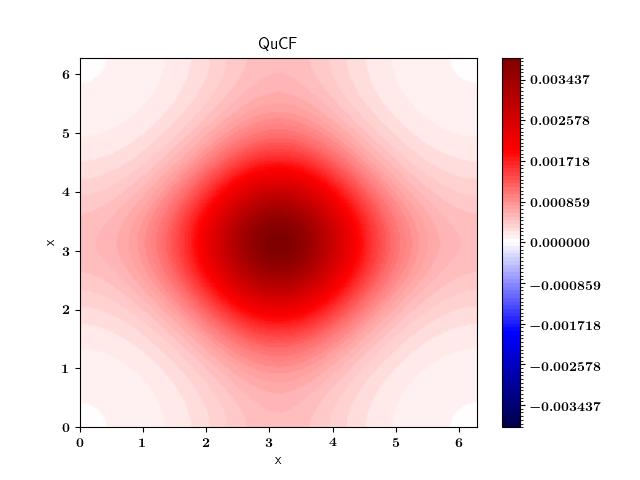

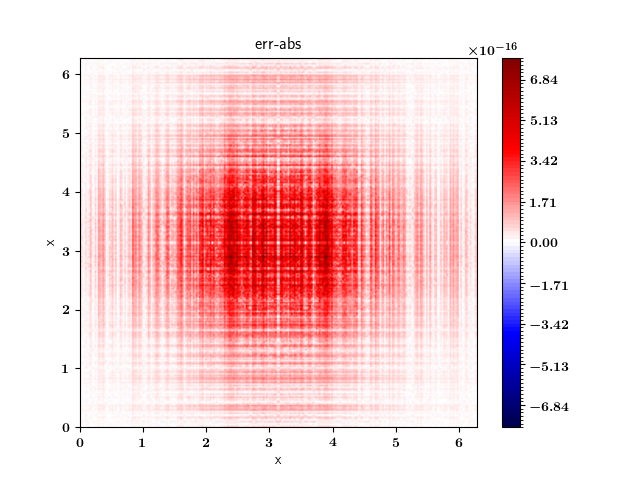

In [5]:
# -------------------------------------------------------------
# --- Compare QuCF (DirDec) and classical initializations ---
# -------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(mse)
def plot_vonMises_1D(mu = np.pi, kappa = 1.0):

    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf_
    om.pname_ = "init_dirdec"
    om.open()

    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    om.set_zero_ancillae_work_states(0)
    f_qucf = om.get_var_x({}, "r")
    f_qucf = f_qucf[:Nx]
    f_qucf = f_qucf.real
    f_qucf *= 2**(nx//2)

    # --- classical data ---
    f_cl = scipy.stats.vonmises.pdf(x, loc=mu, kappa=kappa)
    f_max = scipy.stats.vonmises.pdf(mu, loc=mu, kappa=kappa)
    f_cl /= f_max

    # --- Errors ---
    err_abs = np.abs(f_cl - f_qucf)
    max_err = np.max(err_abs)
    print("max-abs-err: {:0.3e}".format(max_err))

    # --- Plotting ---
    fig1, axs = plt.subplots(1, 2)

    axs[0].plot(x, f_cl,   "-b", label = "CL") 
    axs[0].plot(x, f_qucf, ":r", label = "QuCF") 
    axs[0].set_xlabel('x')
    axs[0].set_ylabel("von Mises")
    axs[0].grid()
    axs[0].legend()

    axs[1].plot(x, err_abs,   "-b") 
    axs[1].set_xlabel('x')
    axs[1].set_ylabel("$|CL - QuCF|$")
    axs[1].grid()

    plt.tight_layout()
    return
# -------------------------------------------------------------
def plot_vonMises_2D(mu = np.pi, kappa = 1.0):
    # ---------------------------------------------------------------------------
    def plot_2D(X, Y, f, str_title=""):
        fig, ax = plt.subplots()

        f_max_loc = np.max(f)

        cmap = plt.get_cmap("seismic")
        levels = np.linspace(-f_max_loc, f_max_loc, 101) 
        divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

        cs = ax.pcolormesh(X, Y, f, cmap=cmap, norm=divnorm, shading='gouraud') 
        cb = fig.colorbar(cs, ax = ax)
        cb.ax.ticklabel_format(style="scientific")

        ax.set_xlabel('x')
        ax.set_ylabel("x")
        ax.set_title(str_title)
        # ax.grid()
        return
    # ---------------------------------------------------------------------------

    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf_
    om.pname_ = "init_dirdec"
    om.open()

    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    om.set_zero_ancillae_work_states(0)
    f_qucf = om.get_var_x({}, "r")
    f_qucf = f_qucf.real
    f_qucf_2D = f_qucf.reshape(Nx, Nx)


    # fig, ax = plt.subplots()
    # ax.plot(range(Nx*Nx), f_qucf, "-r", label = "QuCF") 
    # ax.set_xlabel('x')
    # ax.set_ylabel("von Mises")
    # ax.grid()
    # ax.legend()


    # --- classical data ---
    f_cl = scipy.stats.vonmises.pdf(x, loc=mu, kappa=kappa)
    f_max = scipy.stats.vonmises.pdf(mu, loc=mu, kappa=kappa)
    f_cl /= f_max

    f_cl_2D = np.zeros((Nx, Nx))
    for ii in range(Nx):
        for kk in range(Nx):
            f_cl_2D[ii,kk] = f_cl[ii] * f_cl[kk]

    # --- Errors ---
    err_abs_2D = np.abs(f_cl_2D/np.max(f_cl_2D) - f_qucf_2D/np.max(f_qucf_2D))
    max_err = np.max(err_abs_2D)
    print("max-abs-err: {:0.3e}".format(max_err))

    # --- Plotting ---
    X, Y = np.meshgrid(x, x)
    plot_2D(X, Y, f_cl_2D, "classical")
    plot_2D(X, Y, f_qucf_2D, "QuCF")
    plot_2D(X, Y, err_abs_2D, "err-abs")
    return f_qucf_2D
# -----------------------------------------------------
# plot_vonMises_1D()
f_qucf_2D = plot_vonMises_2D()